<a href="https://colab.research.google.com/github/mumair2305/Captone_Project_2/blob/main/Loan_Default_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing python libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
#Mounting on Google Drive
from google.colab import drive
drive.mount ('/drive')

from google.colab import files

Mounted at /drive


In [3]:
# Read the csv file
df=pd.read_csv("/drive/MyDrive/Loan_status_2007-2020Q3_2_1MM_rows.csv.gz")

/tmp/ipython-input-3-529226629.py:2: DtypeWarning: Columns (1,48,58,117,127,128,129,132,133,134,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/drive/MyDrive/Loan_status_2007-2020Q3_2_1MM_rows.csv.gz")


## DATA CLEANING


# Look at the first 5 rows of the dataframe

In [4]:
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


#
Look at the last five rows of the **dataframe**

In [5]:
df.tail

<bound method NDFrame.tail of          Unnamed: 0         id  loan_amnt  funded_amnt  funded_amnt_inv  \
0                 0    1077501     5000.0       5000.0           4975.0   
1                 1    1077430     2500.0       2500.0           2500.0   
2                 2    1077175     2400.0       2400.0           2400.0   
3                 3    1076863    10000.0      10000.0          10000.0   
4                 4    1075358     3000.0       3000.0           3000.0   
...             ...        ...        ...          ...              ...   
1048570       81262  146495912    20000.0      20000.0          20000.0   
1048571       81263  146702585    10000.0      10000.0          10000.0   
1048572       81264  146789194     7200.0       7200.0           7200.0   
1048573       81265  146750860    25000.0      25000.0          25000.0   
1048574       81266  146652783    40000.0      40000.0          40000.0   

               term int_rate  installment grade sub_grade  ...  \
0         36 months   10.65%       162.87     B        B2  ...   
1         60 months   15.27%        59.83     C        C4  ...   
2         36 months   15.96%        84.33     C        C5  ...   
3         36 months   13.49%       339.31     C        C1  ...   
4         60 months   12.69%        67.79     B        B5  ...   
...             ...      ...          ...   ...       ...  ...   
1048570   60 months    8.19%       407.35     A        A4  ...   
1048571   60 months   15.02%       238.01     C        C3  ...   
1048572   36 months   12.98%       242.53     B        B5  ...   
1048573   60 months   12.98%       568.58     B        B5  ...   
1048574   60 months   11.31%       875.90     B        B3  ...   

        hardship_start_date hardship_end_date payment_plan_start_date  \
0                       NaN               NaN                     NaN   
1                       NaN               NaN                     NaN   
2                       NaN               NaN                     NaN   
3                       NaN               NaN                     NaN   
4                       NaN               NaN                     NaN   
...                     ...               ...                     ...   
1048570                 NaN               NaN                     NaN   
1048571              Apr-20            Jun-20                  Apr-20   
1048572                 NaN               NaN                     NaN   
1048573                 NaN               NaN                     NaN   
1048574                 NaN               NaN                     NaN   

         hardship_length hardship_dpd hardship_loan_status  \
0                    NaN          NaN                  NaN   
1                    NaN          NaN                  NaN   
2                    NaN          NaN                  NaN   
3                    NaN          NaN                  NaN   
4                    NaN          NaN                  NaN   
...                  ...          ...                  ...   
1048570              NaN          NaN                  NaN   
1048571              2.0          0.0               ACTIVE   
1048572              NaN          NaN                  NaN   
1048573              NaN          NaN                  NaN   
1048574              NaN          NaN                  NaN   

        orig_projected_additional_accrued_interest  \
0                                              NaN   
1                                              NaN   
2                                              NaN   
3                                              NaN   
4                                              NaN   
...                                            ...   
1048570                                        NaN   
1048571                                  207.40000   
1048572                                        NaN   
1048573                                  689.61348   
1048574                                        NaN   

     

#Look at the columns and rows of the dataset

In [6]:
df.shape

(1048575, 142)

#Get the descriptive stats for this dataset

In [7]:
df.describe

<bound method NDFrame.describe of          Unnamed: 0         id  loan_amnt  funded_amnt  funded_amnt_inv  \
0                 0    1077501     5000.0       5000.0           4975.0   
1                 1    1077430     2500.0       2500.0           2500.0   
2                 2    1077175     2400.0       2400.0           2400.0   
3                 3    1076863    10000.0      10000.0          10000.0   
4                 4    1075358     3000.0       3000.0           3000.0   
...             ...        ...        ...          ...              ...   
1048570       81262  146495912    20000.0      20000.0          20000.0   
1048571       81263  146702585    10000.0      10000.0          10000.0   
1048572       81264  146789194     7200.0       7200.0           7200.0   
1048573       81265  146750860    25000.0      25000.0          25000.0   
1048574       81266  146652783    40000.0      40000.0          40000.0   

               term int_rate  installment grade sub_grade  ...  \
0         36 months   10.65%       162.87     B        B2  ...   
1         60 months   15.27%        59.83     C        C4  ...   
2         36 months   15.96%        84.33     C        C5  ...   
3         36 months   13.49%       339.31     C        C1  ...   
4         60 months   12.69%        67.79     B        B5  ...   
...             ...      ...          ...   ...       ...  ...   
1048570   60 months    8.19%       407.35     A        A4  ...   
1048571   60 months   15.02%       238.01     C        C3  ...   
1048572   36 months   12.98%       242.53     B        B5  ...   
1048573   60 months   12.98%       568.58     B        B5  ...   
1048574   60 months   11.31%       875.90     B        B3  ...   

        hardship_start_date hardship_end_date payment_plan_start_date  \
0                       NaN               NaN                     NaN   
1                       NaN               NaN                     NaN   
2                       NaN               NaN                     NaN   
3                       NaN               NaN                     NaN   
4                       NaN               NaN                     NaN   
...                     ...               ...                     ...   
1048570                 NaN               NaN                     NaN   
1048571              Apr-20            Jun-20                  Apr-20   
1048572                 NaN               NaN                     NaN   
1048573                 NaN               NaN                     NaN   
1048574                 NaN               NaN                     NaN   

         hardship_length hardship_dpd hardship_loan_status  \
0                    NaN          NaN                  NaN   
1                    NaN          NaN                  NaN   
2                    NaN          NaN                  NaN   
3                    NaN          NaN                  NaN   
4                    NaN          NaN                  NaN   
...                  ...          ...                  ...   
1048570              NaN          NaN                  NaN   
1048571              2.0          0.0               ACTIVE   
1048572              NaN          NaN                  NaN   
1048573              NaN          NaN                  NaN   
1048574              NaN          NaN                  NaN   

        orig_projected_additional_accrued_interest  \
0                                              NaN   
1                                              NaN   
2                                              NaN   
3                                              NaN   
4                                              NaN   
...                                            ...   
1048570                                        NaN   
1048571                                  207.40000   
1048572                                        NaN   
1048573                                  689.61348   
1048574                                        NaN   

 

#Show Column names

In [8]:
column_names = df.columns
print(column_names)

Index(['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_length', 'hardship_dpd', 'hardship_loan_status',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag'],
      dtype='object', length=142)


#Remove extra spaces (leading or trailing) in column names


In [9]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_length', 'hardship_dpd', 'hardship_loan_status',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag'],
      dtype='object', length=142)


#Removing percentage sign from interest rate in each row of the interest rate column

In [10]:
df["int_rate"] = df['int_rate'].str.strip("%").astype("float")

#Print the data type of each column in the data frame

In [11]:
data_types=df.dtypes

print (data_types)

Unnamed: 0                                      int64
id                                             object
loan_amnt                                     float64
funded_amnt                                   float64
funded_amnt_inv                               float64
                                               ...   
hardship_loan_status                           object
orig_projected_additional_accrued_interest    float64
hardship_payoff_balance_amount                float64
hardship_last_payment_amount                  float64
debt_settlement_flag                           object
Length: 142, dtype: object


In [12]:
missing_values = df.isna().sum()


print(missing_values)

Unnamed: 0                                         0
id                                                 0
loan_amnt                                          1
funded_amnt                                        1
funded_amnt_inv                                    1
                                               ...  
hardship_loan_status                          986063
orig_projected_additional_accrued_interest    968950
hardship_payoff_balance_amount                968238
hardship_last_payment_amount                  968238
debt_settlement_flag                               1
Length: 142, dtype: int64


In [13]:
column_order = df.columns
column_index = {col: index for index, col in enumerate(column_order)}

print("Column Order:", column_order)
print("Column Index:", column_index)


Column Order: Index(['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_length', 'hardship_dpd', 'hardship_loan_status',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag'],
      dtype='object', length=142)
Column Index: {'Unnamed: 0': 0, 'id': 1, 'loan_amnt': 2, 'funded_amnt': 3, 'funded_amnt_inv': 4, 'term': 5, 'int_rate': 6, 'installment': 7, 'grade': 8, 'sub_grade': 9, 'emp_title': 10, 'emp_length': 11, 'home_ownership': 12, 'annual_inc': 13, 'verification_status': 14, 'issue_d': 15, 'loan_status': 16, 'pymnt_plan': 17, 'url': 18, 'purpose': 19, 'title': 20, 'zip_code': 21, 'addr_state': 22, 'dti': 23, 'delinq_2yrs': 24, 'earliest_cr_line': 25, 'fico_range_low': 26, 'fico_range_high': 27, 'inq_l

In [14]:
# List of column indices to drop
columns_to_drop = list(range(53, 54))+list(range(56, 82)) + list(range(84, 142))

# Drop the columns
df = df.drop(df.columns[columns_to_drop], axis=1)



In [15]:
# Print the names of the remaining columns
remaining_columns = df.columns
print( len(remaining_columns),remaining_columns)


57 Index(['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title',
       'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'fico_range_low', 'fico_range_high', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'policy_code', 'application_type',
       'delinq_am

In [16]:
# Get the list of column names
remaining_columns = df.columns

# Create a dictionary to map column names to their indices
column_indices = {column: index for index, column in enumerate(remaining_columns)}

# Print the column names and their corresponding indices
for column, index in column_indices.items():
    print(f"Column Name: {column}, Index: {index}")


Column Name: Unnamed: 0, Index: 0
Column Name: id, Index: 1
Column Name: loan_amnt, Index: 2
Column Name: funded_amnt, Index: 3
Column Name: funded_amnt_inv, Index: 4
Column Name: term, Index: 5
Column Name: int_rate, Index: 6
Column Name: installment, Index: 7
Column Name: grade, Index: 8
Column Name: sub_grade, Index: 9
Column Name: emp_title, Index: 10
Column Name: emp_length, Index: 11
Column Name: home_ownership, Index: 12
Column Name: annual_inc, Index: 13
Column Name: verification_status, Index: 14
Column Name: issue_d, Index: 15
Column Name: loan_status, Index: 16
Column Name: pymnt_plan, Index: 17
Column Name: url, Index: 18
Column Name: purpose, Index: 19
Column Name: title, Index: 20
Column Name: zip_code, Index: 21
Column Name: addr_state, Index: 22
Column Name: dti, Index: 23
Column Name: delinq_2yrs, Index: 24
Column Name: earliest_cr_line, Index: 25
Column Name: fico_range_low, Index: 26
Column Name: fico_range_high, Index: 27
Column Name: inq_last_6mths, Index: 28
Colum

In [17]:
df.shape

(1048575, 57)

Outliers in the annual_inc column:
170        225000.0
185        168000.0
333        175000.0
336        208000.0
392        276000.0
             ...   
1048480    190000.0
1048481    200000.0
1048517    400000.0
1048521    210000.0
1048546    325000.0
Name: annual_inc, Length: 50465, dtype: float64


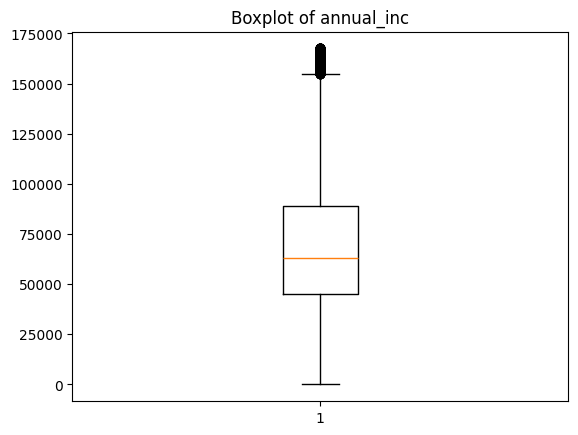

In [18]:


# Define the annual income column we want to check for outliers
income_column = 'annual_inc'

# Calculate the Interquartile Range (IQR)
Q1 = df[income_column].quantile(0.25)
Q3 = df[income_column].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df[income_column] < lower_bound) | (df[income_column] > upper_bound)][income_column]

# Print the outliers
print("Outliers in the", income_column, "column:")
print(outliers)

#Remove outliers from the column
df_outlier_removed = df[(df[income_column] >= lower_bound) & (df[income_column] <= upper_bound)]


# Create a boxplot to visualize outliers
plt.boxplot(df_outlier_removed[income_column])
plt.title("Boxplot of " + income_column)
plt.show()


In [19]:
upper_bound

np.float64(167500.0)

In [20]:
df.shape

(1048575, 57)

## DATA EXPLORATION

#Counting unique values in each category of Purpose, Employee Title and Loan term


In [21]:
purpose_counts = df['purpose'].value_counts()
print(purpose_counts)


purpose
debt_consolidation    567393
credit_card           247541
other                  72340
home_improvement       69540
major_purchase         25356
medical                13746
small_business         12825
car                    12200
house                   9590
vacation                7409
moving                  7171
wedding                 2340
renewable_energy         700
educational              423
Name: count, dtype: int64


In [22]:
emp_title_counts = df['emp_title'].value_counts()
print(emp_title_counts.head(10))


emp_title
Teacher             15536
Manager             14013
Owner                9324
Driver               7111
Registered Nurse     6419
Supervisor           5550
RN                   5402
Sales                5164
Project Manager      4127
Office Manager       3932
Name: count, dtype: int64


In [23]:
term_counts = df['term'].value_counts()
print(term_counts)


term
36 months    745828
60 months    302746
Name: count, dtype: int64


#Count top 5 subgrades


In [24]:
top_subgrades = df['sub_grade'].value_counts().head(5)
print(top_subgrades)
print("Top 5 Loan Subgrades")


sub_grade
B4    66928
B2    63641
C1    62044
B5    61330
B3    60729
Name: count, dtype: int64
Top 5 Loan Subgrades


# Default Rate based on Employee Length


In [25]:
#Count unique values in employee length and loan status columns
df[["emp_length", "loan_status"]].value_counts()

emp_length  loan_status
10+ years   Fully Paid     149172
            Current        143448
< 1 year    Current         45191
2 years     Fully Paid      42920
< 1 year    Fully Paid      40868
                            ...  
4 years     Default             7
6 years     Default             6
7 years     Default             5
9 years     Default             3
8 years     Default             2
Name: count, Length: 99, dtype: int64

In [26]:
# filtering the dataset for loans that have defaulted for each category of employment length
df[df["loan_status"]=="Default"]["emp_length"].value_counts()

,count
emp_length,
10+ years,46
1 year,15
< 1 year,15
3 years,14
5 years,10
2 years,8
4 years,7
6 years,6
7 years,5


In [27]:
# Showing the default rate for different employment lengths
(df[df["loan_status"]=="Default"]["emp_length"].value_counts()*100/ df["emp_length"].value_counts())

,count
emp_length,
1 year,0.021745
10+ years,0.013837
2 years,0.008519
3 years,0.016722
4 years,0.010719
5 years,0.014732
6 years,0.012049
7 years,0.011697
8 years,0.005596


annual_inc_bucket
<40k        0.139268
40k-60k     0.125761
60k-80k     0.116030
80k-100k    0.106268
100k+       0.089821
Name: loan_status, dtype: float64


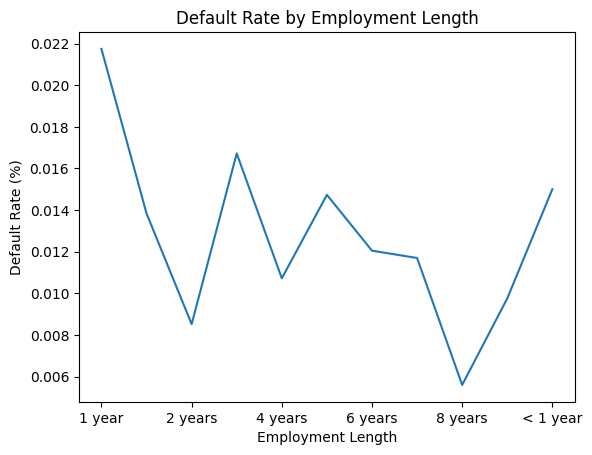

In [69]:
import matplotlib.pyplot as plt

# Plot the trendline
(df[df["loan_status"] == "Default"]["emp_length"].value_counts() * 100 / df["emp_length"].value_counts()).plot()
print(default_rates)

# Add labels
plt.title("Default Rate by Employment Length")
plt.xlabel("Employment Length")
plt.ylabel("Default Rate (%)")

plt.show()


#Default Rate based on Annual Income

/tmp/ipython-input-68-1886632062.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



annual_inc_bucket
<40k        0.139268
40k-60k     0.125761
60k-80k     0.116030
80k-100k    0.106268
100k+       0.089821
Name: loan_status, dtype: float64


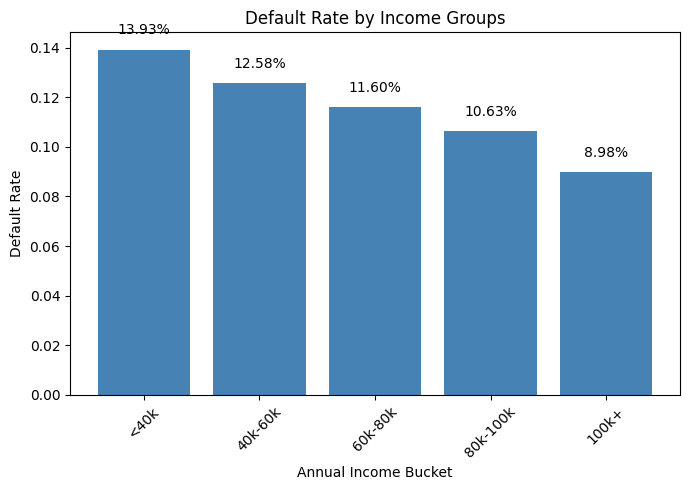

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Select relevant columns and copying it to a new dataframe 'df_annualinc_loan_status'
df_annualinc_loan_status = df[["annual_inc", "loan_status"]].copy()

# Step 2: Define income bins and labels
income_bins = [0, 40000, 60000, 80000, 100000, float('inf')]
income_labels = ['<40k', '40k-60k', '60k-80k', '80k-100k', '100k+']

# Step 3: Create 'annual_inc_bucket' column
df_annualinc_loan_status['annual_inc_bucket'] = pd.cut(
    df_annualinc_loan_status["annual_inc"],
    bins=income_bins,
    labels=income_labels,
    right=False
)

# Step 4: Calculate default rates per income bucket
default_rates = df_annualinc_loan_status.groupby('annual_inc_bucket')['loan_status'].apply(
    lambda x: (x == 'Charged Off').mean()
)
print(default_rates)

# Step 5: Plot the bar chart
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the bar chart
bars = ax.bar(default_rates.index.astype(str), default_rates.values, color='steelblue')

# Add labels and title
ax.set_title("Default Rate by Income Groups")
ax.set_xlabel("Annual Income Bucket")
ax.set_ylabel("Default Rate")

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.2%}",
        ha='center', va='bottom'
    )

# Rotate x labels if needed
plt.xticks(rotation=45)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()









#Default Rate in Various Interest Rate Groups


/tmp/ipython-input-30-3013335126.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rates = df_annualint_loan_status.groupby('int_rate_bucket')['loan_status'].apply(lambda x: (x == 'Charged Off').mean())


Loan Default Rates by Interest Rate Bucket:
int_rate_bucket
<10%       0.046648
10%-15%    0.102375
15%-20%    0.168668
20%+       0.244728
Name: loan_status, dtype: float64


<Axes: title={'center': 'Default Rate by Interest Rate'}, ylabel='loan_status'>

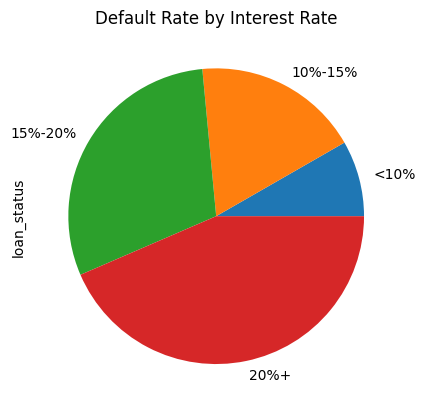

In [30]:
#Selecting columns int_rate and loan_status from data frame
df_annualint_loan_status = df[["int_rate", "loan_status"]].copy()


# Define interest rate buckets
interest_rate_bins = [5, 10, 15, 20, float('inf')]
interest_rate_labels = ['<10%', '10%-15%', '15%-20%', '20%+']

# Create 'int_rate_bucket' column using cut
df_annualint_loan_status['int_rate_bucket'] = pd.cut(df_annualint_loan_status['int_rate'], bins=interest_rate_bins, labels=interest_rate_labels, right=False)

# Calculate loan default rates for each interest rate bucket
default_rates = df_annualint_loan_status.groupby('int_rate_bucket')['loan_status'].apply(lambda x: (x == 'Charged Off').mean())

print("Loan Default Rates by Interest Rate Bucket:")
print(default_rates)

#Plot a visual
(default_rates).plot.pie(title="Default Rate by Interest Rate")


#Loan Status VS DTI Debt to Income Ratio

/tmp/ipython-input-31-2355582822.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rates = df_dti_loan_status.groupby('dti_bucket')['loan_status'].apply(lambda x: (x == 'Charged Off').mean())


Loan Default Rates by DTI Bucket:
dti_bucket
0-15     0.103635
15-20    0.112860
20-25    0.123353
25+      0.131020
Name: loan_status, dtype: float64


<Axes: title={'center': 'Default Rate by Debt to Income Ratio'}, ylabel='loan_status'>

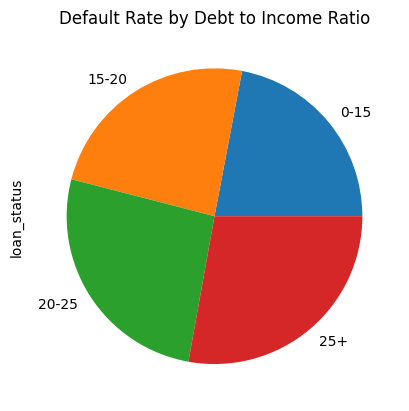

In [31]:
#Select columns "dti" and "loan_status" from dataframe
df_dti_loan_status = df[["dti", "loan_status"]].copy()

# Define DTI buckets
dti_bins = [0, 15, 20, 25, float('inf')]
dti_labels = ['0-15', '15-20', '20-25', '25+']

# Create 'dti_bucket' column using cut
df_dti_loan_status['dti_bucket'] = pd.cut(df_dti_loan_status['dti'], bins=dti_bins, labels=dti_labels, right=False)

# Calculate loan default rates for each DTI bucket
default_rates = df_dti_loan_status.groupby('dti_bucket')['loan_status'].apply(lambda x: (x == 'Charged Off').mean())

print("Loan Default Rates by DTI Bucket:")
print(default_rates)

#Plot a visual
(default_rates).plot.pie(title="Default Rate by Debt to Income Ratio")


#Impact of Loan Grade on Default Rate

Loan Default Rates by Grade (%)
grade
A    0.004885
B    0.015359
C    0.019306
D    0.021163
E    0.032082
F    0.023093
G         NaN
Name: count, dtype: float64


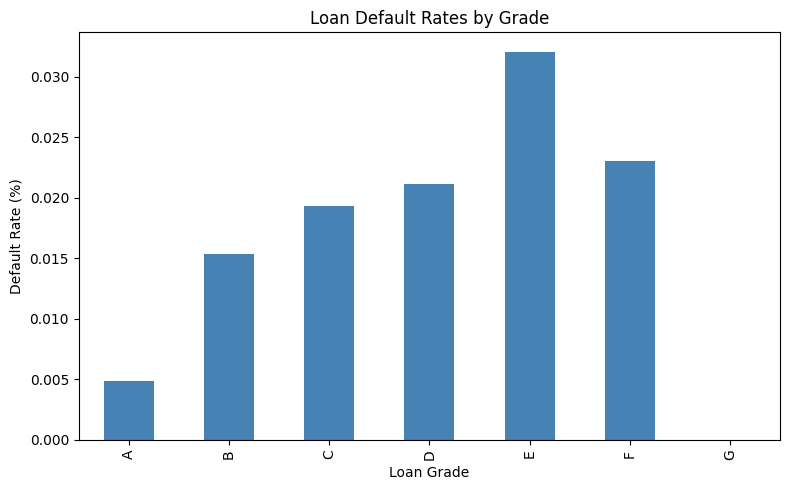

In [65]:
import matplotlib.pyplot as plt

# Step 1: Calculate loan default rate (%) by grade
Loan_default_bygrade = (
    df[df["loan_status"] == "Default"]["grade"].value_counts() * 100
    / df["grade"].value_counts()
)

# Step 2: Print the result
print("Loan Default Rates by Grade (%)")
print(Loan_default_bygrade)

# Step 3: Plot
fig, ax = plt.subplots(figsize=(8, 5))

Loan_default_bygrade.sort_index().plot.bar(
    ax=ax,
    color='steelblue',
    title="Loan Default Rates by Grade"
)

# Add axis labels
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate (%)")

# Improve layout
plt.tight_layout()

# Show plot
plt.show()



#Relationship between Loan Status and FICO Score


In [61]:
#Createing a new DataFrame, df_fico_loan_status, that contains a copy of the columns "fico_range_low," "fico_range_high," and "loan_status" from the original DataFrame df

df_fico_loan_status = df[["fico_range_low","fico_range_high","loan_status"]].copy()


# Define FICO score buckets
def get_fico_bucket(fico_low, fico_high):
    avg_fico = (fico_low + fico_high) // 2

    if avg_fico < 600:
        return 'Poor'
    elif avg_fico < 700:
        return 'Fair'
    elif avg_fico < 750:
        return 'Good'
    else:
        return 'Excellent'

# Create a new column 'fico_bucket' based on FICO scores
df['fico_bucket'] = df.apply(lambda row: get_fico_bucket(row['fico_range_low'], row['fico_range_high']), axis=1)



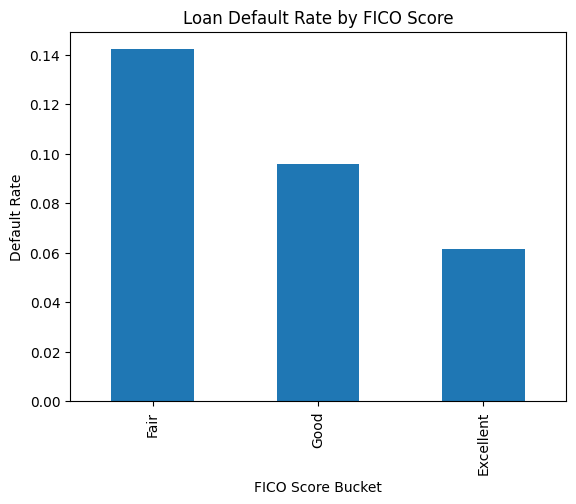

Loan Default Rates by FICO Score 
fico_bucket
Fair         0.142168
Good         0.095935
Excellent    0.061710
Name: count, dtype: float64


In [62]:

# Calculate the default rate by FICO score bucket
default_rate_by_bucket = df[df['loan_status'] == 'Charged Off']['fico_bucket'].value_counts() / df['fico_bucket'].value_counts()

#Plot
import matplotlib.pyplot as plt

# Plot
default_rate_by_bucket.plot.bar(title="Loan Default Rate by FICO Score")
plt.ylabel("Default Rate")
plt.xlabel("FICO Score Bucket")  # Optional: add x-axis label for clarity
plt.show()

print("Loan Default Rates by FICO Score ")
print(default_rate_by_bucket)


#Relationship of Loan Status with Purpose of Borrowing

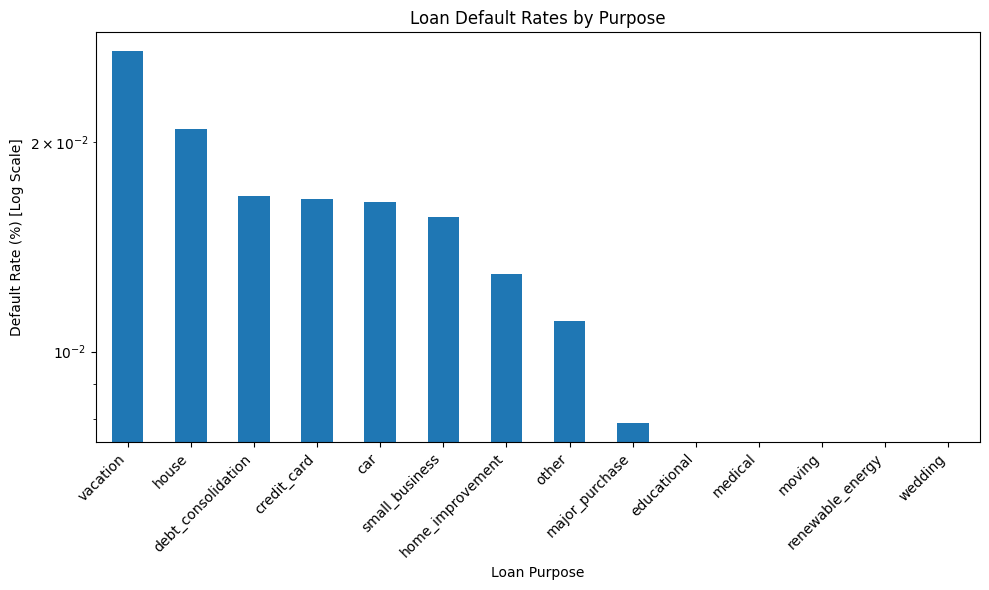

Loan Default Rates by Purpose (in %):
purpose
vacation              0.026994
house                 0.020855
debt_consolidation    0.016743
credit_card           0.016563
car                   0.016393
small_business        0.015595
home_improvement      0.012942
other                 0.011059
major_purchase        0.007888
educational                NaN
medical                    NaN
moving                     NaN
renewable_energy           NaN
wedding                    NaN
Name: count, dtype: float64


In [55]:
import matplotlib.pyplot as plt

# Step 1: Calculate loan default rate (%) by purpose
Loan_default_by_purpose = (
    df[df["loan_status"] == "Default"]["purpose"].value_counts() * 100
    / df["purpose"].value_counts()
)

# Step 2: Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))

Loan_default_by_purpose.sort_values(ascending=False).plot.bar(
    ax=ax,
    log=True,  # Apply log scale
    title="Loan Default Rates by Purpose"
)

# Step 3: Add axis labels
ax.set_xlabel("Loan Purpose")
ax.set_ylabel("Default Rate (%) [Log Scale]")

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

# Step 4: Print results
print("Loan Default Rates by Purpose (in %):")
print(Loan_default_by_purpose.sort_values(ascending=False))





#Correlation Matrix of Columns

                 loan_amnt  annual_inc  delinq_2yrs  funded_amnt  int_rate  \
loan_amnt         1.000000    0.157345    -0.012437     0.999529  0.051110   
annual_inc        0.157345    1.000000     0.024692     0.157271 -0.036139   
delinq_2yrs      -0.012437    0.024692     1.000000    -0.012291  0.094940   
funded_amnt       0.999529    0.157271    -0.012291     1.000000  0.051118   
int_rate          0.051110   -0.036139     0.094940     0.051118  1.000000   
funded_amnt_inv   0.998155    0.156963    -0.012133     0.998737  0.051321   
open_acc          0.180215    0.088892     0.039769     0.180474 -0.013572   
total_acc         0.191351    0.104191     0.108237     0.191045 -0.033787   
dti               0.059073   -0.064244    -0.012933     0.059412  0.099781   

                 funded_amnt_inv  open_acc  total_acc       dti  
loan_amnt               0.998155  0.180215   0.191351  0.059073  
annual_inc              0.156963  0.088892   0.104191 -0.064244  
delinq_2yrs          

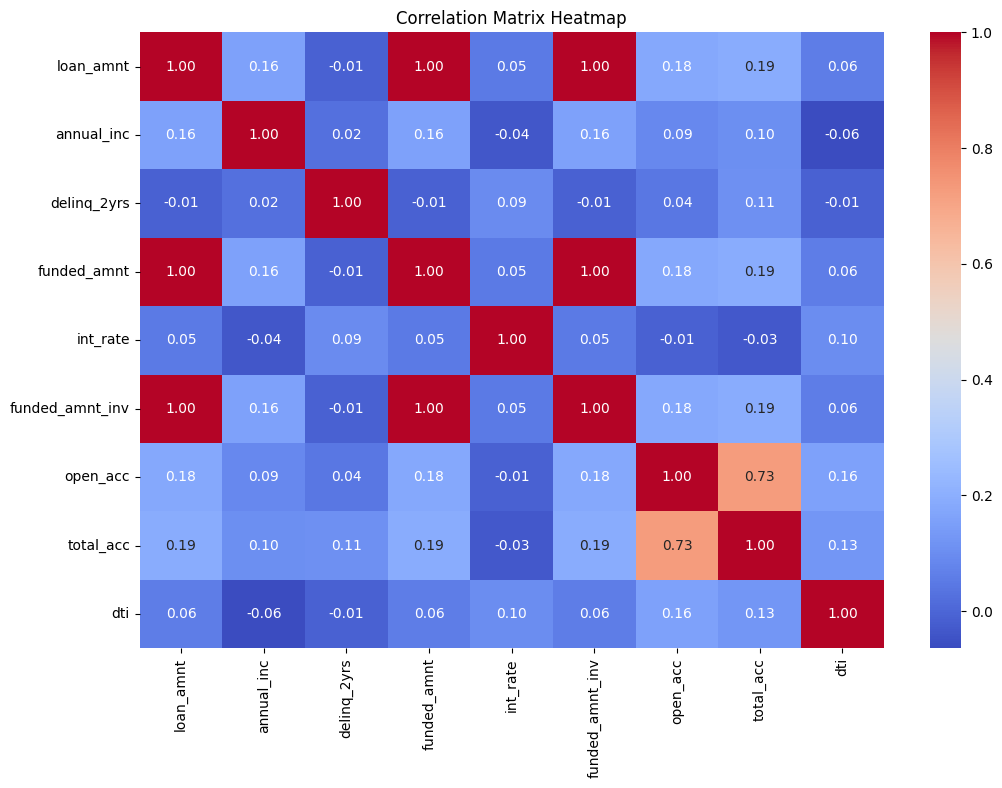

In [36]:
# Creating a DataFrame containing the specified columns
selected_columns = df[['loan_amnt','annual_inc','delinq_2yrs',
                         'funded_amnt','int_rate','funded_amnt_inv', 'open_acc', 'total_acc','dti']]

# Calculating the correlation matrix
correlation_matrix = selected_columns.corr()

# Print the correlation matrix
print(correlation_matrix)

#plot
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()



In [37]:
selected_columns

,loan_amnt,annual_inc,delinq_2yrs,funded_amnt,int_rate,funded_amnt_inv,open_acc,total_acc,dti
0,5000.0,24000.0,0.0,5000.0,10.65,4975.0,3.0,9.0,27.65
1,2500.0,30000.0,0.0,2500.0,15.27,2500.0,3.0,4.0,1.00
2,2400.0,12252.0,0.0,2400.0,15.96,2400.0,2.0,10.0,8.72
3,10000.0,49200.0,0.0,10000.0,13.49,10000.0,10.0,37.0,20.00
4,3000.0,80000.0,0.0,3000.0,12.69,3000.0,15.0,38.0,17.94
...,...,...,...,...,...,...,...,...,...
1048570,20000.0,50000.0,1.0,20000.0,8.19,20000.0,13.0,29.0,18.12
1048571,10000.0,32905.0,0.0,10000.0,15.02,10000.0,4.0,11.0,4.27
1048572,7200.0,120000.0,0.0,7200.0,12.98,7200.0,22.0,33.0,14.99
1048573,25000.0,86000.0,0.0,25000.0,12.98,25000.0,10.0,30.0,29.84


In [38]:
  # 1. loan_amnt has a strong positive correlation with funded_amnt and funded_amnt_inv. This suggests that these columns are closely related and move together. For instance, if the loan amount (loan_amnt) increases, the funded amount (funded_amnt) and the amount funded by investors (funded_amnt_inv) tend to increase as well.

 #  2. int_rate has a positive correlation with loan_amnt. This indicates that as the loan amount increases, the interest rate (int_rate) tends to be higher. Borrowers requesting larger loans might receive them at slightly higher interest rates.

  # 3. open_acc and total_acc are positively correlated. Borrowers with a higher number of open credit lines (open_acc) tend to have more total accounts (total_acc). This relationship makes sense, as individuals with more open accounts generally have a larger total number of accounts.

  # 4.As_integer_ratio dti (debt-to-income ratio) has a positive correlation with int_rate. This suggests that, as the interest rate on a loan increases, the borrower's debt-to-income ratio (dti) also tends to increase. Borrowers with higher interest rates may have higher debt-to-income ratios.

#Loan Status Distribution


Number of loans in each Loan status category
loan_status
Fully Paid                                             467733
Current                                                442209
Charged Off                                            120684
Late (31-120 days)                                       8752
In Grace Period                                          4948
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1336
Does not meet the credit policy. Status:Charged Off       761
Default                                                   163
Name: count, dtype: int64


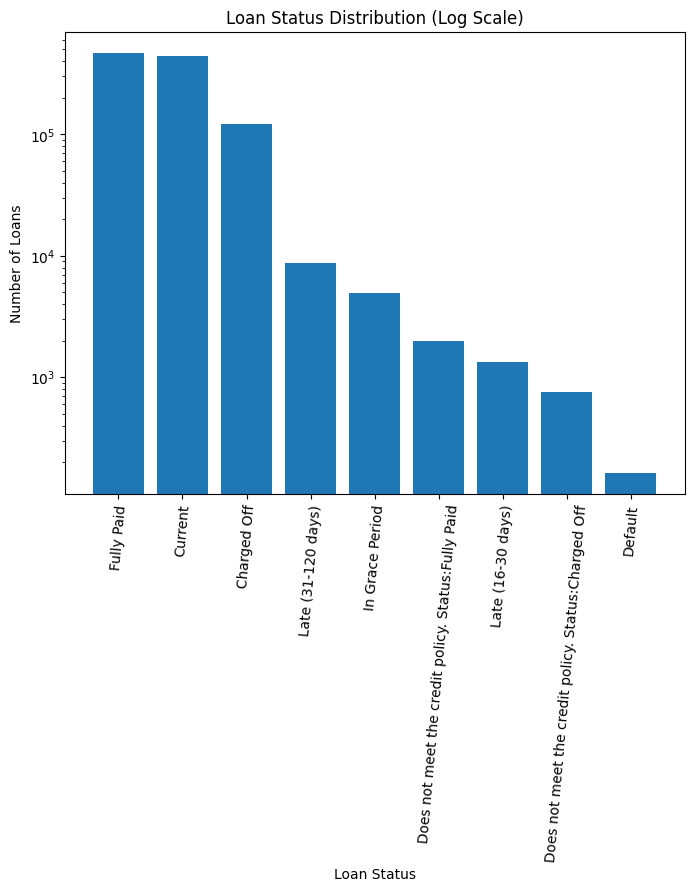

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Count the occurrences of each unique value in the 'loan_status' column of the DataFrame
loan_status_counts = df['loan_status'].value_counts()
print("Number of loans in each Loan status category")
print(loan_status_counts)

# Plot with log scale on y-axis
plt.figure(figsize=(8, 6))
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title("Loan Status Distribution (Log Scale)")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.yscale('log')
plt.xticks(rotation=85)
plt.show()


#Loan Amount by Loan status

Loan Amount by Loan Status
loan_status
Charged Off                                            1.956559e+09
Current                                                7.243977e+09
Default                                                2.935825e+06
Does not meet the credit policy. Status:Charged Off    7.250225e+06
Does not meet the credit policy. Status:Fully Paid     1.760022e+07
Fully Paid                                             6.587559e+09
In Grace Period                                        8.799382e+07
Late (16-30 days)                                      2.204058e+07
Late (31-120 days)                                     1.504568e+08
Name: loan_amnt, dtype: float64


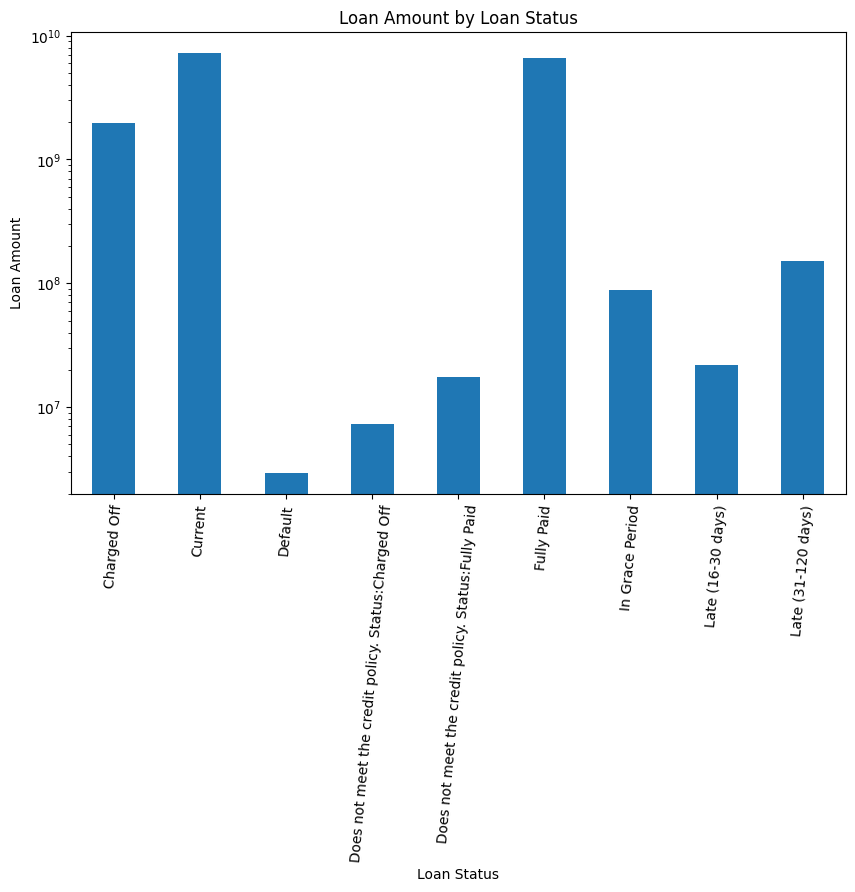

In [57]:
# Group the data by "loan_status" and calculate the sum of "loan_amnt"
loan_amount_by_status = df.groupby('loan_status')['loan_amnt'].sum()
print ("Loan Amount by Loan Status")
print(loan_amount_by_status)

# Create a bar plot
plt.figure(figsize=(10, 6))
loan_amount_by_status.plot(kind='bar')
plt.yscale('log')
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.xticks(rotation=85)
plt.show()





#Default rate by Grade


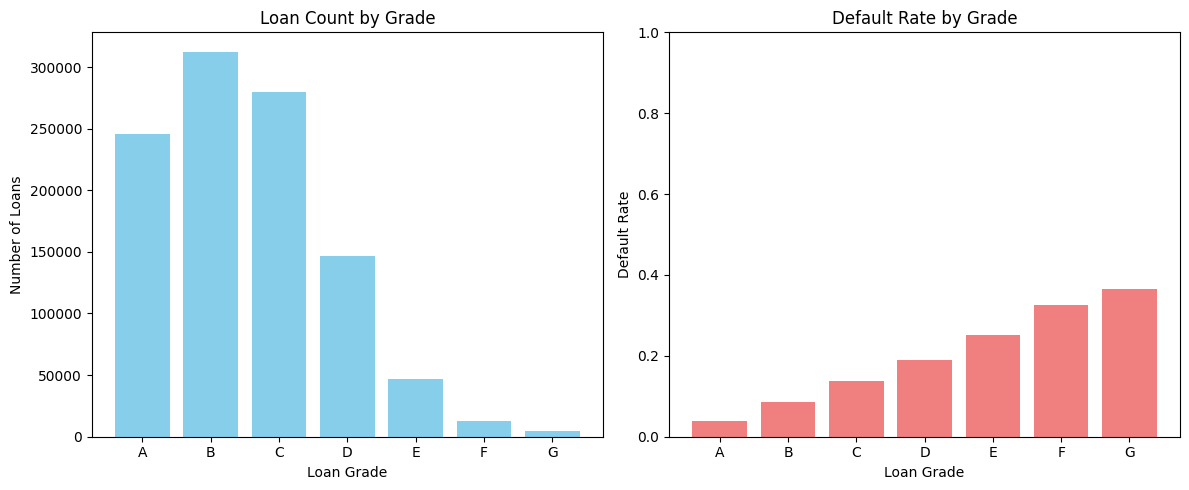

In [58]:
# Group the data by 'grade' and calculate the count of loans
loan_count_by_grade = df['grade'].value_counts().sort_index()

# Group the data by 'grade' and calculate the default rate
default_rate_by_grade = df[df['loan_status'] == 'Charged Off']['grade'].value_counts().sort_index() / loan_count_by_grade

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot the count of loans by grade
ax1.bar(loan_count_by_grade.index, loan_count_by_grade, color='skyblue')
ax1.set_title('Loan Count by Grade')
ax1.set_xlabel('Loan Grade')
ax1.set_ylabel('Number of Loans')

# Plot the default rate by grade
ax2.bar(default_rate_by_grade.index, default_rate_by_grade, color='lightcoral')
ax2.set_title('Default Rate by Grade')
ax2.set_xlabel('Loan Grade')
ax2.set_ylabel('Default Rate')
ax2.set_ylim(0, 1)  # Set the y-axis limit to [0, 1] for default rate

plt.tight_layout()
plt.show()



#Count and Default Rate by State

In [60]:
import plotly.express as px
import pandas as pd

# Prepare Default Rate DataFrame
default_df = default_rate_by_state.reset_index()
default_df.columns = ['state', 'default_rate']

# Prepare Loan Count DataFrame
loan_count_df = loan_count_by_state.reset_index()
loan_count_df.columns = ['state', 'loan_count']

# ---- MAP 1: Default Rate by State ----
fig1 = px.choropleth(
    default_df,
    locations='state',
    locationmode='USA-states',
    color='default_rate',
    scope='usa',
    color_continuous_scale='Reds',
    title='Loan Default Rate by State'
)
fig1.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'), margin={"r":0,"t":30,"l":0,"b":0})

# ---- MAP 2: Loan Count by State ----
fig2 = px.choropleth(
    loan_count_df,
    locations='state',
    locationmode='USA-states',
    color='loan_count',
    scope='usa',
    color_continuous_scale='Blues',
    title='Total Number of Loans by State'
)
fig2.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'), margin={"r":0,"t":30,"l":0,"b":0})

# Show both maps
fig1.show()
fig2.show()


#Employment length analysis by other factors like loan grades or loan purposes

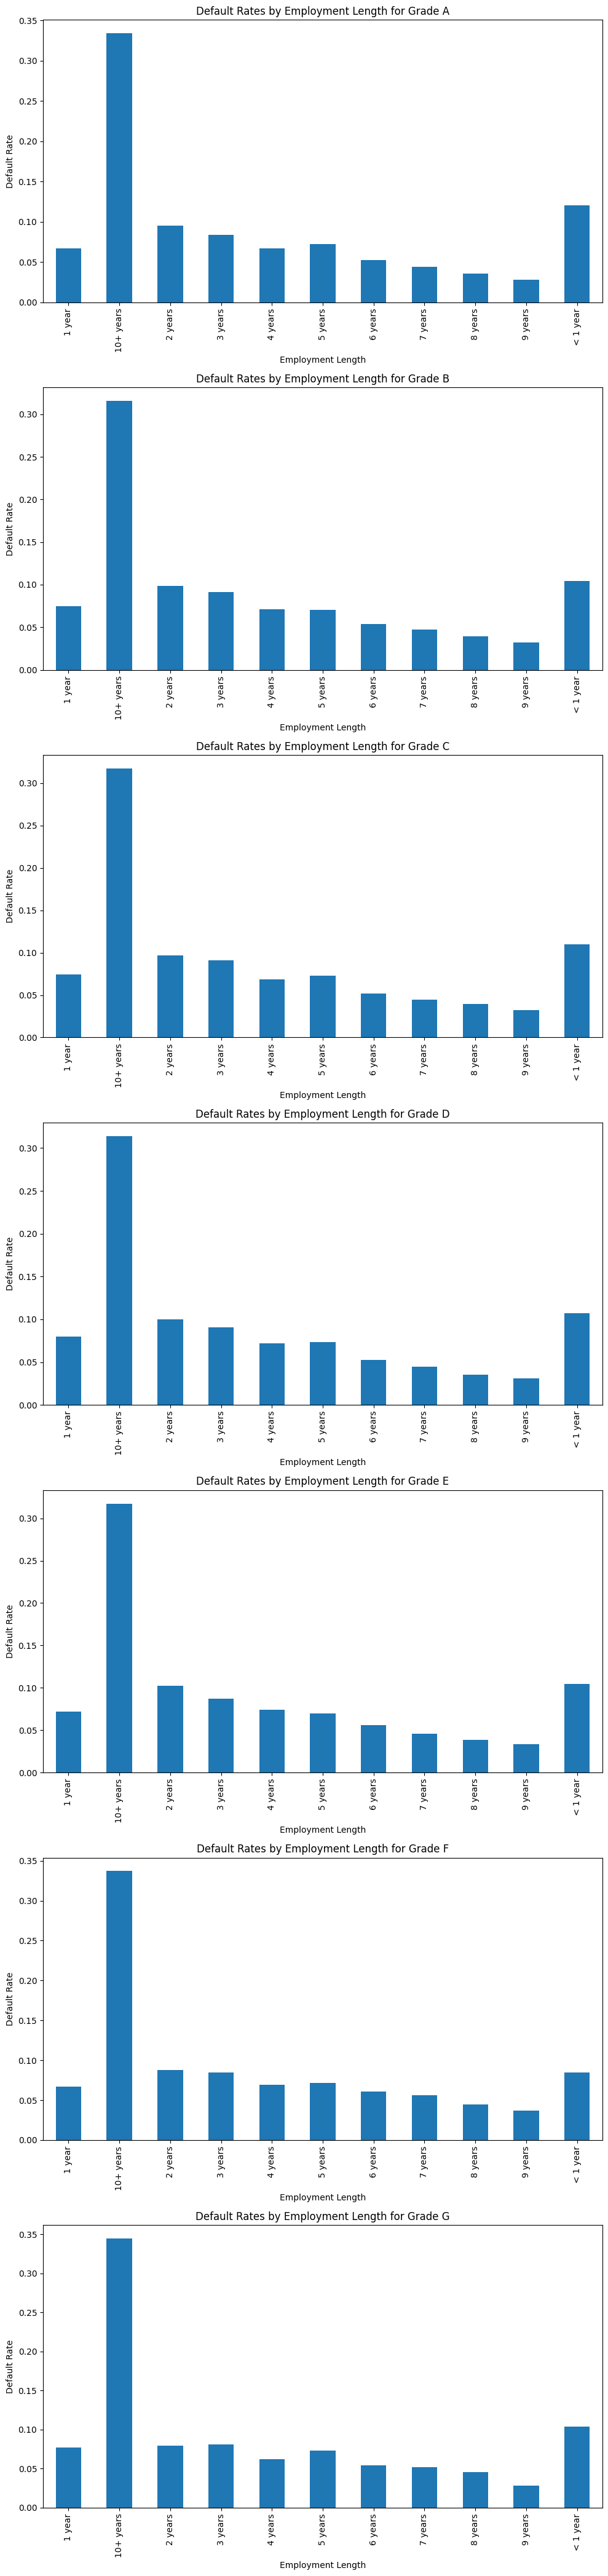

In [44]:
# 'loan_status', 'grade', and 'emp_length' are columns use in this code from DataFrame 'df'

# Filter data for charged off loans
charged_off_loans = df[df['loan_status'] == 'Charged Off']

# Define loan grades
loan_grades = sorted(charged_off_loans['grade'].unique())

#print(loan_grades)

# Create subplots to display default rates for each grade
fig, axs = plt.subplots(nrows=len(loan_grades), ncols=1,figsize=(10, 6 * len(loan_grades)))

# Calculate and plot default rates for each loan grade
for i, grade in enumerate(loan_grades):
    default_rates = charged_off_loans[charged_off_loans['grade'] == grade]['emp_length'].value_counts(normalize=True).sort_index()
    ax = axs[i]
    default_rates.plot(kind='bar',ax=ax)
    ax.set_title(f"Default Rates by Employment Length for Grade {grade}")
    ax.set_xlabel("Employment Length")
    ax.set_ylabel("Default Rate")

plt.tight_layout()
plt.show()


#Loan Volume by Year and Grade


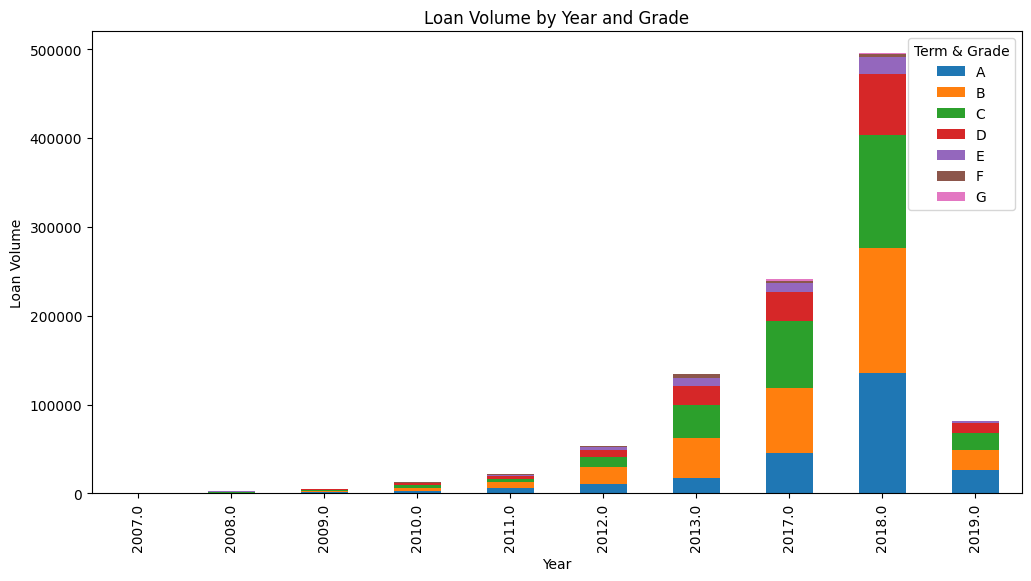

In [45]:
# The 'issue_d' column contains loan issue dates, converting it to a datetime object
df['issue_datetime'] = pd.to_datetime(df['issue_d'], format="%b-%y")

# Extracting the year from the 'issue_d' column
df['issue_year'] = df['issue_datetime'].dt.year

# Grouping the data by year, term, and grade, and count the number of loans in each group
loan_volume = df.groupby(['issue_year', 'grade']).size().reset_index(name='loan_count')

# Pivoting the DataFrame to make it suitable for plotting
loan_volume_pivot = loan_volume.pivot_table(index='issue_year', columns=['grade'], values='loan_count', fill_value=0)

# Create a bar plot
loan_volume_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Loan Volume by Year and Grade')
plt.xlabel('Year')
plt.ylabel('Loan Volume')
plt.legend(title='Term & Grade')
plt.show()


#Loan application Count by Loan repayment and loan status


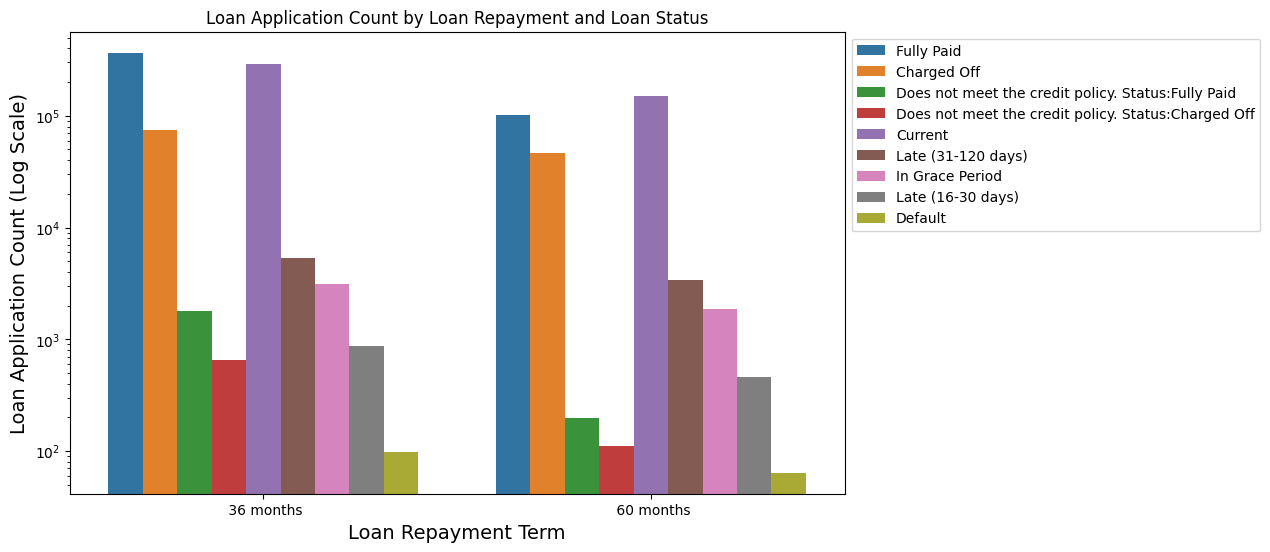

In [46]:
ax.set_yscale("log")
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(x="term", data=df, hue='loan_status')

# Set titles and labels
ax.set(title='Loan Application Count by Loan Repayment and Loan Status')
ax.set_xlabel('Loan Repayment Term', fontsize=14)
ax.set_ylabel('Loan Application Count (Log Scale)', fontsize=14)

# Set log scale on y-axis
ax.set_yscale("log")

# Legend placement
ax.legend(bbox_to_anchor=(1, 1))

plt.show()

